In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [136]:
df=pd.read_csv("height-weight1.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [137]:
x=df[['Weight']]
y=df[['Height']]
x

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


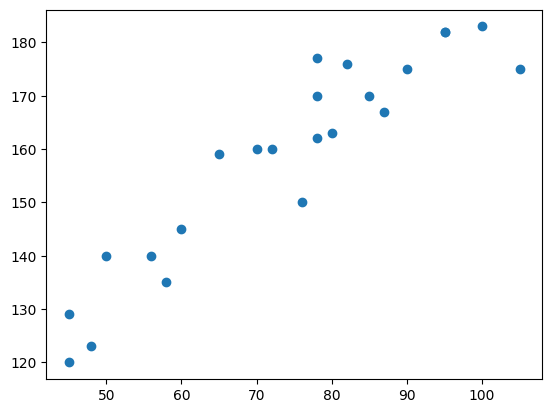

In [138]:
plt.scatter(x,y)
plt.show()

In [139]:
#trfain test split
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=42)

In [140]:
xtrain

,Weight
1,58
13,100
5,78
2,48
11,95
20,45
3,60
4,70
18,76
16,50


In [141]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
xtrain=scaler.fit_transform(xtrain)
xtest=scaler.transform(xtest)

In [142]:
from sklearn.linear_model import LinearRegression
regress=LinearRegression()
regress.fit(xtrain,ytrain)

LinearRegression()

In [143]:
y_predict=regress.predict(xtest)

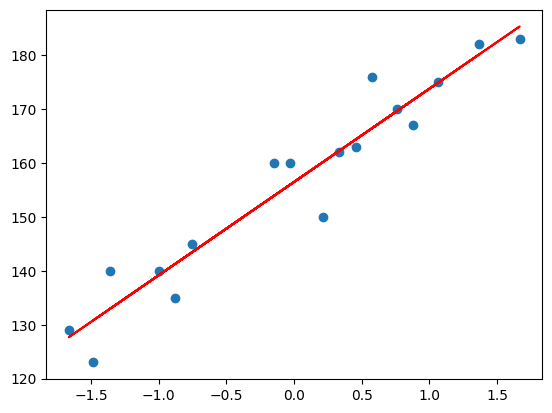

In [144]:
plt.scatter(xtrain,ytrain)
plt.plot(xtrain,regress.predict(xtrain),'r' )
plt.show()


In [145]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print(mean_squared_error(y_predict,ytest))
print(mean_absolute_error(y_predict,ytest))
print(np.sqrt(mean_squared_error(y_predict,ytest)))

114.84069295228699
9.665125886795005
10.716374991212605


In [146]:
from sklearn.metrics import r2_score
r2=r2_score(y_predict,ytest)
print(r2)

0.7242334405003443


In [147]:
adjustedr2=1-(1-r2)*(len(ytest)-1)/(len(ytest)-xtest.shape[1]-1)
print(adjustedr2)

0.6552918006254305


In [148]:
#for new data point 
weight=[[59]]
sweight=scaler.transform(weight)
result=regress.predict(sweight)
result[0]

c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([142.3544217])

In [149]:
residuals=y_predict-ytest
residuals

,Height
15,-14.735003
9,-7.735003
0,7.683471
8,-1.920277
17,-10.358028
12,15.558973


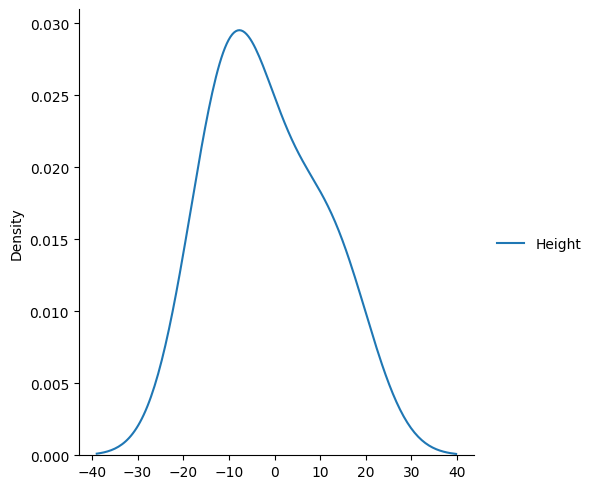

In [150]:

sns.displot(residuals,kind='kde',legend=True)

plt.show()